In [7]:
!pip install -q segmentation-models-pytorch albumentations geopandas rasterio


In [8]:
import os
import sys
import warnings
import time
import json
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio import features
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import binary_dilation
from copy import deepcopy
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm 

warnings.filterwarnings('ignore')
os.environ['CPL_LOG'] = '/dev/null'
print('Python    :', sys.version.split()[0])
print('PyTorch   :', torch.__version__)
print('CUDA avail:', torch.cuda.is_available())
print('GPU count :', torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}   : {torch.cuda.get_device_name(i)}')


Python    : 3.12.12
PyTorch   : 2.10.0+cu128
CUDA avail: True
GPU count : 2
  GPU 0   : Tesla T4
  GPU 1   : Tesla T4


In [9]:
BASE_DIR = Path('/kaggle/input/datasets/amerii/spacenet-7-multitemporal-urban-development')

print("Dataset structure:")
for p in sorted(BASE_DIR.iterdir()):
    print(f"  {p.name}/")
    if p.is_dir():
        sub = list(p.iterdir())[:3]
        for s in sub:
            print(f"    {s.name}")

Dataset structure:
  SN7_buildings_test_public/
    test_public
  SN7_buildings_train/
    train
  SN7_buildings_train_csvs/
    csvs
  SN7_buildings_train_sample/
    sample


In [30]:

BASE_DIR  = Path('/kaggle/input/datasets/amerii/spacenet-7-multitemporal-urban-development')
TRAIN_DIR = BASE_DIR / 'SN7_buildings_train' / 'train'

CFG = {
    'ignore_index' : 255,
    'num_classes'  : 2,
    'img_size'     : (512, 512),
    'epochs'       : 5,
    'batch_size'   : 8,       # 8 per GPU on 2x T4 via DataParallel
    'lr'           : 1e-4,
    'weight_decay' : 1e-5,
    'val_split'    : 0.15,
    'num_workers'  : 2,
    'default_ratio'    : 0.01,
    'default_strategy' : 'boundary',
    'save_dir'     : Path('./outputs'),
    'seed'         : 42,
}

CFG['save_dir'].mkdir(parents=True, exist_ok=True)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device : {DEVICE}   GPUs in use: {N_GPUS}')

Device : cuda   GPUs in use: 2


In [4]:
def collect_pairs(root: Path):
    image_paths = []
    mask_paths  = []

    aois = [p for p in root.iterdir() if p.is_dir()]
    print(f'Scanning {len(aois)} AOI folders ...')

    for aoi in sorted(aois):
        img_dir  = aoi / 'images_masked'
        mask_dir = aoi / 'labels_match_pix'
        if not img_dir.exists() or not mask_dir.exists():
            continue

        mask_dict = {
            m.stem.replace('_Buildings', ''): m
            for m in mask_dir.glob('*.geojson')
        }

        for img_p in sorted(img_dir.glob('*.tif')):
            if img_p.stem in mask_dict:
                image_paths.append(str(img_p))
                mask_paths.append(str(mask_dict[img_p.stem]))

    return image_paths, mask_paths


all_imgs, all_masks = collect_pairs(TRAIN_DIR)
print(f'Total matched pairs found: {len(all_imgs)}')

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_imgs, all_masks, test_size=CFG['val_split'], random_state=CFG['seed']
)
print(f'Train: {len(train_imgs)}   Val: {len(val_imgs)}')

Scanning 60 AOI folders ...
Total matched pairs found: 1423
Train: 1209   Val: 214


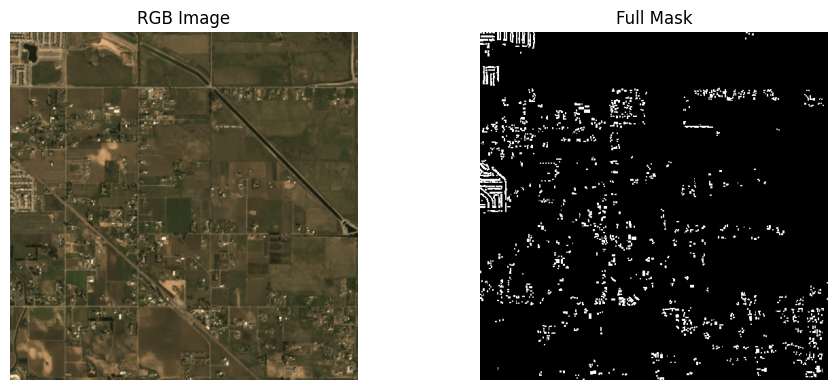

Image shape: (512, 512, 3)   Mask unique values: [0 1]


In [5]:
def read_image(path: str) -> np.ndarray:
    """
    Read a GeoTIFF using rasterio instead of cv2.
    cv2 passes GeoTIFFs to GDAL which prints a warning for every
    non-standard metadata tag (33550, 33922 etc).
    Rasterio reads the same pixels silently.
    """
    with rasterio.open(path) as src:
        if src.count >= 3:
            img = src.read([1, 2, 3])          # (3, H, W)
        else:
            ch  = src.read(1)
            img = np.stack([ch, ch, ch])

    img = np.transpose(img, (1, 2, 0))         # -> (H, W, 3)

    if img.dtype != np.uint8:
        lo, hi = img.min(), img.max()
        img = ((img - lo) / (hi - lo + 1e-8) * 255).astype(np.uint8)

    return cv2.resize(img, CFG['img_size'])


def read_mask_from_geojson(geojson_path: str, native_shape: tuple = (1024, 1024)) -> np.ndarray:
    """Rasterise building polygons into a binary mask (0=background, 1=building)."""
    gdf = gpd.read_file(geojson_path)

    if gdf.empty:
        mask = np.zeros(native_shape, dtype=np.uint8)
    else:
        mask = features.rasterize(
            [(geom, 1) for geom in gdf.geometry],
            out_shape=native_shape,
            fill=0,
            all_touched=True,
            dtype=np.uint8,
        )

    return cv2.resize(mask, CFG['img_size'], interpolation=cv2.INTER_NEAREST)


# Sanity check
if all_imgs:
    _img  = read_image(all_imgs[0])
    _mask = read_mask_from_geojson(all_masks[0])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(_img);             axes[0].set_title('RGB Image')
    axes[1].imshow(_mask, cmap='gray'); axes[1].set_title('Full Mask')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Image shape: {_img.shape}   Mask unique values: {np.unique(_mask)}')

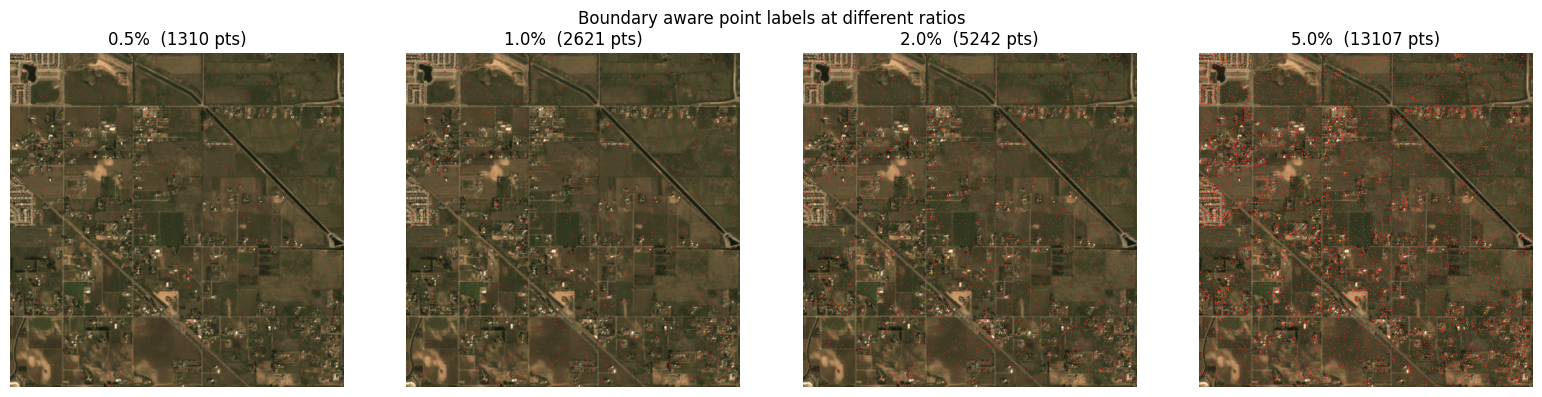

In [36]:
IGNORE = CFG['ignore_index']  # 255


def sample_random(mask: np.ndarray, ratio: float = 0.01) -> np.ndarray:
    """
    Uniform random point sampling.
    Picks `ratio` fraction of pixels at random and labels them.
    All other pixels get IGNORE so they produce no gradient.
    """
    H, W   = mask.shape
    n      = max(2, int(H * W * ratio))
    flat   = mask.ravel()
    pm     = np.full(H * W, IGNORE, dtype=np.int64)
    chosen = np.random.choice(H * W, size=n, replace=False)
    pm[chosen] = flat[chosen]
    return pm.reshape(H, W)


def sample_boundary_aware(
    mask              : np.ndarray,
    ratio             : float = 0.01,
    boundary_fraction : float = 0.5,
) -> np.ndarray:
    """
    Boundary-aware point sampling.
    Half the budget goes to pixels near building edges (detected via
    binary dilation), the rest goes to interior/background pixels.
    """
    H, W    = mask.shape
    n_total = max(2, int(H * W * ratio))
    flat    = mask.ravel()
    pm      = np.full(H * W, IGNORE, dtype=np.int64)

    building = (mask == 1).astype(np.uint8)
    dilated  = binary_dilation(building, iterations=3).astype(np.uint8)
    boundary = (dilated - building).ravel()

    b_idx = np.where(boundary > 0)[0]
    i_idx = np.where(boundary == 0)[0]

    n_b = min(int(n_total * boundary_fraction), len(b_idx))
    n_i = n_total - n_b

    if n_b > 0 and len(b_idx) > 0:
        sel_b     = np.random.choice(b_idx, size=n_b, replace=False)
        pm[sel_b] = flat[sel_b]

    if n_i > 0 and len(i_idx) > 0:
        sel_i     = np.random.choice(i_idx, size=min(n_i, len(i_idx)), replace=False)
        pm[sel_i] = flat[sel_i]

    return pm.reshape(H, W)


def make_point_mask(mask, strategy='boundary', ratio=0.01):
    if strategy == 'boundary':
        return sample_boundary_aware(mask, ratio)
    return sample_random(mask, ratio)


# Visualise point labels on top of the actual RGB image
if all_imgs:
    ratios = [0.005, 0.01, 0.02, 0.05]
    fig, axes = plt.subplots(1, len(ratios), figsize=(16, 4))

    for ax, r in zip(axes, ratios):
        pm  = sample_boundary_aware(_mask, ratio=r)
        vis = _img.copy()
        vis[pm == 1] = [255, 200, 0]   # building points -> yellow
        vis[pm == 0] = [255, 50,  50]  # background points -> red
        ax.imshow(vis)
        ax.set_title(f'{r*100:.1f}%  ({int((pm != IGNORE).sum())} pts)')
        ax.axis('off')

    plt.suptitle('Boundary aware point labels at different ratios')
    plt.tight_layout()
    plt.savefig(CFG['save_dir'] / 'point_labels.png', dpi=100)
    plt.show()

In [21]:
class SpaceNet7Dataset(Dataset):

    def __init__(self, img_paths, mask_paths, strategy='boundary',
                 ratio=0.01, transform=None, is_val=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.strategy   = strategy
        self.ratio      = ratio
        self.transform  = transform
        self.is_val     = is_val

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img       = read_image(self.img_paths[idx])
        full_mask = read_mask_from_geojson(self.mask_paths[idx])

        if self.is_val:
            sup_mask = full_mask.astype(np.int64)
        else:
            sup_mask = make_point_mask(full_mask, self.strategy, self.ratio)

        if self.transform is not None:
            aug      = self.transform(image=img, mask=sup_mask.astype(np.int32))
            img      = aug['image']
            sup_mask = aug['mask'].long()
        else:
            img      = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            sup_mask = torch.from_numpy(sup_mask.astype(np.int64))

        return img, sup_mask


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [14]:
class PartialCrossEntropyLoss(nn.Module):

    def __init__(self, ignore_index: int = 255):
        super().__init__()
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index, reduction='none')

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred   : (B, C, H, W)
        # target : (B, H, W) with ignore_index for unlabelled pixels
        loss_map     = self.ce(pred, target)
        labeled_mask = (target != self.ignore_index).float()

        n_labeled = labeled_mask.sum()
        if n_labeled == 0:
            return loss_map.sum() * 0.0

        return (loss_map * labeled_mask).sum() / n_labeled

In [15]:
def compute_iou(pred_logits, gt_mask, num_classes=2, ignore_index=255):

    preds = pred_logits.argmax(dim=1)
    valid = (gt_mask != ignore_index)
    preds = preds[valid].cpu().numpy()
    gt    = gt_mask[valid].cpu().numpy()

    iou_per_class = []
    for c in range(num_classes):
        tp = ((preds == c) & (gt == c)).sum()
        fp = ((preds == c) & (gt != c)).sum()
        fn = ((preds != c) & (gt == c)).sum()
        denom = tp + fp + fn
        iou_per_class.append(tp / denom if denom > 0 else 0.0)

    return float(np.mean(iou_per_class))

In [41]:
def build_model(encoder='efficientnet-b3', pretrained=True):
    
    # DeepLabV3+ with EfficientNet-B3 encoder.
   
    model = smp.DeepLabV3Plus(
        encoder_name    = encoder,
        encoder_weights = 'imagenet' if pretrained else None,
        in_channels     = 3,
        classes         = CFG['num_classes'],
    )

    if N_GPUS > 1:
        print(f'Running on dual GPU')
        model = nn.DataParallel(model)

    return model.to(DEVICE)

In [27]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [Train]', leave=True,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for step, (images, masks) in enumerate(pbar, 1):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        avg_loss      = running_loss / step

        pbar.set_postfix(loss=f'{avg_loss:.4f}')

    return running_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0.0
    total_iou  = 0.0

    pbar = tqdm(loader, desc='           [Val]  ', leave=True,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, masks in pbar:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        logits   = model(images)
        loss     = F.cross_entropy(logits, masks, ignore_index=CFG['ignore_index'])
        iou      = compute_iou(logits, masks, CFG['num_classes'], CFG['ignore_index'])

        total_loss += loss.item()
        total_iou  += iou

        pbar.set_postfix(loss=f'{loss.item():.4f}', mIoU=f'{iou:.4f}')

    n = len(loader)
    return total_loss / n, total_iou / n

In [45]:
import gc
import time
import torch
from torch.utils.data import DataLoader

def run_experiment(run_name, train_imgs, val_imgs,
                   train_masks, val_masks,
                   strategy='boundary', ratio=0.01, epochs=None):

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    epochs = epochs or CFG['epochs']

    print(f'\nStarting run')
    print(f'Sampling strategy: {strategy} for Label ratio: {ratio*100:.1f}%')
    print('-' * 45)

    train_ds = SpaceNet7Dataset(
        train_imgs, train_masks,
        strategy=strategy,
        ratio=ratio,
        transform=train_transform,
        is_val=False
    )

    val_ds = SpaceNet7Dataset(
        val_imgs, val_masks,
        strategy=strategy,
        ratio=ratio,
        transform=val_transform,
        is_val=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG['batch_size'],
        shuffle=True,
        num_workers=CFG['num_workers'],
        pin_memory=True,
        persistent_workers=False,
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=CFG['batch_size'],
        shuffle=False,
        num_workers=CFG['num_workers'],
        pin_memory=True,
        persistent_workers=False
    )

    model = build_model()
    criterion = PartialCrossEntropyLoss(ignore_index=CFG['ignore_index'])

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CFG['lr'],
        weight_decay=CFG['weight_decay']
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )

    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    best_iou = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
        val_loss, val_iou = validate(model, val_loader)

        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(
                model.state_dict(),
                CFG['save_dir'] / f'{run_name}_best.pth'
            )

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'train_loss {tr_loss:.4f} | '
            f'val_loss {val_loss:.4f} | '
            f'val_mIoU {val_iou:.4f} | '
            f'{time.time() - t0:.0f}s'
        )

    del model, optimizer, scheduler, train_loader, val_loader
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'Best val mIoU for {run_name}: {best_iou:.4f}')
    return history, best_iou

In [46]:
EXP1_RATIOS  = [0.005, 0.01, 0.02, 0.05]
exp1_results = {}

for r in EXP1_RATIOS:
    name = f'ratio_{int(r*1000):04d}'
    hist, best_iou = run_experiment(
        run_name=name,
        train_imgs=train_imgs, val_imgs=val_imgs,
        train_masks=train_masks, val_masks=val_masks,
        strategy='boundary', ratio=r,
        epochs=CFG['epochs'],
    )
    exp1_results[r] = {'history': hist, 'best_iou': best_iou}

print('Experiment to find minimum number of points label needed, done succesfully')


Starting run
Sampling strategy: boundary for Label ratio: 0.5%
---------------------------------------------
Running on dual GPU


           [Val]  : 100%|██████████████████████████████| 27/27 [01:02<00:00,  2.31s/it, loss=0.2908, mIoU=0.4480]


Epoch 01/5 | train_loss 0.3828 | val_loss 0.3170 | val_mIoU 0.4476 | 404s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:02<00:00,  2.30s/it, loss=0.2507, mIoU=0.4492]


Epoch 02/5 | train_loss 0.2335 | val_loss 0.2768 | val_mIoU 0.4482 | 409s


...

Epoch 03/5 | train_loss 0.2124 | val_loss 0.2515 | val_mIoU 0.4626 | 433s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.48s/it, loss=0.2325, mIoU=0.4543]


Epoch 04/5 | train_loss 0.2074 | val_loss 0.2513 | val_mIoU 0.4650 | 424s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.46s/it, loss=0.2306, mIoU=0.4550]


Epoch 05/5 | train_loss 0.2051 | val_loss 0.2500 | val_mIoU 0.4693 | 423s
Best val mIoU for ratio_0050: 0.4693
Experiment to find minimum number of points label needed, done succesfully


In [48]:
EXP2_STRATEGIES = ['random', 'boundary']
exp2_results    = {}

for strat in EXP2_STRATEGIES:
    name = f'strategy_{strat}'
    hist, best_iou = run_experiment(
        run_name=name,
        train_imgs=train_imgs, val_imgs=val_imgs,
        train_masks=train_masks, val_masks=val_masks,
        strategy=strat, ratio=0.01,
        epochs=CFG['epochs'],
    )
    exp2_results[strat] = {'history': hist, 'best_iou': best_iou}

print('Sampling strategy comparison sucessfully done')


Starting run
Sampling strategy: random for Label ratio: 1.0%
---------------------------------------------
Running on dual GPU


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.47s/it, loss=0.2417, mIoU=0.5618]


Epoch 01/5 | train_loss 0.3764 | val_loss 0.2623 | val_mIoU 0.5051 | 427s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.46s/it, loss=0.2123, mIoU=0.6115]


Epoch 02/5 | train_loss 0.2384 | val_loss 0.2325 | val_mIoU 0.5555 | 418s


...

Epoch 03/5 | train_loss 0.2088 | val_loss 0.2500 | val_mIoU 0.4656 | 424s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.46s/it, loss=0.2276, mIoU=0.4613]


Epoch 04/5 | train_loss 0.2051 | val_loss 0.2457 | val_mIoU 0.4759 | 428s


           [Val]  : 100%|██████████████████████████████| 27/27 [01:06<00:00,  2.45s/it, loss=0.2273, mIoU=0.4630]


Epoch 05/5 | train_loss 0.2039 | val_loss 0.2460 | val_mIoU 0.4755 | 422s
Best val mIoU for strategy_boundary: 0.4759
Sampling strategy comparison sucessfully done


In [ ]:
def plot_results(results, title, label_map):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for k, v in results.items():
        axes[0].plot(v['history']['val_iou'], label=label_map[k])
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Val mIoU')
    axes[0].set_title(title + ' - Learning Curves')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    labels    = [label_map[k] for k in results]
    best_ious = [v['best_iou'] for v in results.values()]
    bars = axes[1].bar(labels, best_ious, color='steelblue', edgecolor='black')
    for bar, val in zip(bars, best_ious):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.002,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1].set_ylabel('Best Val mIoU')
    axes[1].set_title(title + ' - Best mIoU')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(CFG['save_dir'] / f'{title.replace(" ","_").lower()}.png', dpi=120)
    plt.show()

plot_results(exp1_results, 'Exp1: Sampling Ratio',
             {r: f'{r*100:.1f}%' for r in EXP1_RATIOS})

plot_results(exp2_results, 'Exp2: Sampling Strategy',
             {'random': 'Random', 'boundary': 'Boundary-Aware'})
rows = []
for r, v in exp1_results.items():
    rows.append({'Experiment': 'Ratio', 'Config': f'{r*100:.1f}%', 'Best mIoU': round(v['best_iou'], 4)})
for s, v in exp2_results.items():
    rows.append({'Experiment': 'Strategy', 'Config': s.capitalize(), 'Best mIoU': round(v['best_iou'], 4)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(CFG['save_dir'] / 'results_summary.csv', index=False)